In [1]:
# CONFIGURATION
import os
import warnings
import logging

from dotenv import load_dotenv
load_dotenv()

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

import numpy as np
import random

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Paths
TRAIN_PATH = "data/training_scaled.csv"
VAL_PATH = "data/val_scaled.csv"
TEST_PATH = "data/test_scaled.csv"
SCALER_PATH = "artifacts/minmax_scaler.pkl"
PREPROC_PATH = "data/nsrdb_preprocessed.csv"
DAILY_SCALER_PATH = "artifacts/daily_minmax_scaler.pkl"
DAILY_TRAIN_PATH = "data/nsrdb_daily_train.csv"
DAILY_VAL_PATH = "data/nsrdb_daily_val.csv"
DAILY_TRAIN_SCALED_PATH = "data/daily_train_scaled.csv"
DAILY_VAL_SCALED_PATH = "data/daily_val_scaled.csv"

# Sequence config
TARGET_COL = "ghi"
WINDOW_SIZE = 24 # hours
DAILY_WINDOW = 30 # days
SHORT_HORIZONS = [6, 12]
MEDIUM_HORIZONS = [7, 14]
LONG_HORIZONS = [28, 56, 84, 168, 336]
PROPHET_REGRESSORS = ["temperature", "relative_humidity", "wind_speed", "solar_zenith_angle" , "surface_albedo"]

# XGBoost hyper-parameters
XGB_N_ESTIMATORS = 500
XGB_LEARNING_RATE = 0.05
XGB_MAX_DEPTH = 6
XGB_EARLY_STOPPING = 20

# LSTM hyper-parameters
LSTM_UNITS_1 = 128
LSTM_UNITS_2 = 64
DROPOUT_RATE = 0.2
DENSE_UNITS = 32
EPOCHS = 100
BATCH_SIZE = 64
PATIENCE = 10
LEARNING_RATE = 0.001

# Cross validation settings
XGB_N_SPLITS = 5 # folds for XGBoost CV
LSTM_N_SPLITS = 5 # folds for LSTM CV (higher training cost)

os.makedirs("outputs", exist_ok=True)

In [2]:
# IMPORTS
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb

import tensorflow as tf
tf.random.set_seed(RANDOM_SEED)

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

from prophet import Prophet
from prophet.diagnostics import cross_validation as prophet_cv
from prophet.diagnostics import performance_metrics

print("All imports successful")

I0000 00:00:1780275654.363735  258036 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


All imports successful


In [3]:
# LOAD DATA
# Hourly scaled splits
train_scaled = pd.read_csv(TRAIN_PATH, index_col="datetime", parse_dates=True)
val_scaled = pd.read_csv(VAL_PATH, index_col="datetime", parse_dates=True)

# Merge train + val to form the full CV pool (test is never used here)
cv_scaled = pd.concat([train_scaled, val_scaled]).sort_index()

# Unscaled full dataset (for Prophet)
df_full = pd.read_csv(PREPROC_PATH, index_col="datetime", parse_dates=True)
n_full = len(df_full)
cv_raw = df_full.iloc[: int(n_full * 0.85)]   # train+val share

# Fitted scaler (used to invert predictions back to W/m^2)
scaler = joblib.load(SCALER_PATH)
daily_scaler = joblib.load(DAILY_SCALER_PATH)

feature_cols = cv_scaled.columns.tolist()
target_idx = feature_cols.index(TARGET_COL)

# Daily scaled splits
daily_train_scaled = pd.read_csv(DAILY_TRAIN_SCALED_PATH, index_col="datetime", parse_dates=True)
daily_val_scaled = pd.read_csv(DAILY_VAL_SCALED_PATH, index_col="datetime", parse_dates=True)
cv_daily_scaled = pd.concat([daily_train_scaled, daily_val_scaled]).sort_index()

# Daily unscaled splits (for Prophet long horizon)
daily_train_raw = pd.read_csv(DAILY_TRAIN_PATH, index_col="datetime", parse_dates=True)
daily_val_raw = pd.read_csv(DAILY_VAL_PATH, index_col="datetime", parse_dates=True)
cv_daily_raw = pd.concat([daily_train_raw, daily_val_raw]).sort_index()

daily_feature_cols = cv_daily_scaled.columns.tolist()
daily_target_idx = daily_feature_cols.index(TARGET_COL)

print(f"Hourly CV pool: {cv_scaled.shape}")
print(f"Daily CV pool: {cv_daily_scaled.shape}")

Hourly CV pool: (74521, 17)
Daily CV pool: (3105, 15)


In [4]:
# SHARED HELPERS
def build_sequences(data: np.ndarray, window: int, horizons: list, tgt_idx: int):
    X, ys = [], {h: [] for h in horizons}
    max_h = max(horizons)
    for i in range(window, len(data) - max_h + 1):
        X.append(data[i - window: i, :])
        for h in horizons:
            ys[h].append(data[i + h - 1, tgt_idx])
    return np.array(X), {h: np.array(v) for h, v in ys.items()}

def invert_ghi(scaled_vals: np.ndarray) -> np.ndarray:
    dummy = np.zeros((len(scaled_vals), scaler.n_features_in_))
    dummy[:, target_idx] = scaled_vals
    return scaler.inverse_transform(dummy)[:, target_idx]

def invert_daily_ghi(scaled_vals: np.ndarray) -> np.ndarray:
    dummy = np.zeros((len(scaled_vals), daily_scaler.n_features_in_))
    dummy[:, daily_target_idx] = scaled_vals
    return daily_scaler.inverse_transform(dummy)[:, daily_target_idx]

def regression_metrics(y_true, y_pred, label=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    if label:
        print(f"{label:<30} MAE={mae:7.2f} RMSE={rmse:7.2f} R^2={r2:.4f}")
    return {"mae": mae, "rmse": rmse, "r2": r2}

def build_lstm(n_features: int, n_outputs: int) -> Sequential:
    model = Sequential([
        Input(shape=(WINDOW_SIZE, n_features)),
        LSTM(LSTM_UNITS_1, return_sequences=True, use_cudnn=False),
        Dropout(DROPOUT_RATE),
        LSTM(LSTM_UNITS_2, return_sequences=False, use_cudnn=False),
        Dropout(DROPOUT_RATE),
        Dense(DENSE_UNITS, activation="relu"),
        Dense(n_outputs),
    ])
    model.compile(optimizer=Adam(LEARNING_RATE), loss="mse", metrics=["mae"])
    return model


# Collect all fold level results in one list for the final summary CSV
all_results = []

In [5]:
# XGBOOST – SHORT HORIZON
# Build all sequences from the CV pool first, then split the sequence array with TimeSeriesSplit.
# This preserves temporal order: no future data ever leaks into a training fold.
print("XGBOOST SHORT HORIZON CROSS VALIDATION (hourly 6h/12h)")

cv_arr = cv_scaled.values
X_cv, y_cv = build_sequences(cv_arr, WINDOW_SIZE, SHORT_HORIZONS, target_idx)
X_cv_flat = X_cv.reshape(X_cv.shape[0], -1)

tscv = TimeSeriesSplit(n_splits=XGB_N_SPLITS)

for h in SHORT_HORIZONS:
    print(f"\nHorizon h={h}h - {XGB_N_SPLITS} fold walk forward CV")
    fold_results = []

    for fold_idx, (tr_idx, val_idx) in enumerate(tscv.split(X_cv_flat)):
        Xtr, Xval = X_cv_flat[tr_idx], X_cv_flat[val_idx]
        ytr, yval = y_cv[h][tr_idx], y_cv[h][val_idx]

        model = xgb.XGBRegressor(
            n_estimators = XGB_N_ESTIMATORS,
            learning_rate = XGB_LEARNING_RATE,
            max_depth = XGB_MAX_DEPTH,
            early_stopping_rounds = XGB_EARLY_STOPPING,
            random_state = RANDOM_SEED,
            verbosity = 0,
            device="cuda",
            n_jobs=1,
        )
        model.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)

        preds_scaled = model.predict(Xval)
        y_true_real = invert_ghi(yval)
        y_pred_real = invert_ghi(preds_scaled)

        m = regression_metrics(y_true_real, y_pred_real, label=f"fold {fold_idx + 1}")
        m.update({"model": "XGBoost", "horizon": f"{h}h", "fold": fold_idx + 1, "train_size": len(tr_idx), "val_size": len(val_idx)})
        fold_results.append(m)
        all_results.append(m)

    # Fold summary
    mean_mae = np.mean([r["mae"] for r in fold_results])
    mean_rmse = np.mean([r["rmse"] for r in fold_results])
    mean_r2 = np.mean([r["r2"] for r in fold_results])
    std_mae = np.std( [r["mae"] for r in fold_results])
    print(f"Mean across folds: MAE={mean_mae:.2f} +- {std_mae:.2f} RMSE={mean_rmse:.2f} R^2={mean_r2:.4f}")
          

XGBOOST SHORT HORIZON CROSS VALIDATION (hourly 6h/12h)

Horizon h=6h - 5 fold walk forward CV


sh: line 1: nvidia-smi: command not found


fold 1                         MAE=  51.44 RMSE=  98.52 R^2=0.8653


fold 2                         MAE=  41.16 RMSE=  86.00 R^2=0.8662


fold 3                         MAE=  54.53 RMSE= 104.70 R^2=0.8490


...

fold 1                         MAE=  56.08 RMSE= 101.90 R^2=0.8558


fold 2                         MAE=  47.02 RMSE=  93.63 R^2=0.8415


fold 3                         MAE=  59.87 RMSE= 112.24 R^2=0.8268


fold 4                         MAE=  46.41 RMSE=  89.65 R^2=0.8513


fold 5                         MAE=  53.62 RMSE= 104.64 R^2=0.8382
Mean across folds: MAE=52.60 +- 5.21 RMSE=100.41 R^2=0.8427


In [6]:
# XGBOOST – MEDIUM HORIZON
print("XGBOOST MEDIUM HORIZON CROSS VALIDATION (daily 7d/14d)")

cv_daily_arr = cv_daily_scaled.values
X_daily_cv, y_daily_cv = build_sequences(cv_daily_arr, DAILY_WINDOW, MEDIUM_HORIZONS, daily_target_idx)
X_daily_cv_flat = X_daily_cv.reshape(X_daily_cv.shape[0], -1)

tscv_daily = TimeSeriesSplit(n_splits=XGB_N_SPLITS)

for h in MEDIUM_HORIZONS:
    print(f"\nHorizon h={h}d - {XGB_N_SPLITS} fold walk forward CV")
    fold_results = []

    for fold_idx, (tr_idx, val_idx) in enumerate(tscv_daily.split(X_daily_cv_flat)):
        Xtr, Xval = X_daily_cv_flat[tr_idx], X_daily_cv_flat[val_idx]
        ytr, yval = y_daily_cv[h][tr_idx], y_daily_cv[h][val_idx]

        model = xgb.XGBRegressor(
            n_estimators = XGB_N_ESTIMATORS,
            learning_rate = XGB_LEARNING_RATE,
            max_depth = XGB_MAX_DEPTH,
            early_stopping_rounds = XGB_EARLY_STOPPING,
            random_state = RANDOM_SEED,
            verbosity = 0,
            device="cuda",
            n_jobs=1,
        )
        model.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)

        preds_scaled = model.predict(Xval)
        y_true_real = invert_daily_ghi(yval)
        y_pred_real = invert_daily_ghi(preds_scaled)

        m = regression_metrics(y_true_real, y_pred_real, label=f"fold {fold_idx + 1}")
        m.update({"model": "XGBoost_daily", "horizon": f"{h}d", "fold": fold_idx + 1, "train_size": len(tr_idx), "val_size": len(val_idx)})
        fold_results.append(m)
        all_results.append(m)

    mean_mae = np.mean([r["mae"] for r in fold_results])
    mean_rmse = np.mean([r["rmse"] for r in fold_results])
    mean_r2 = np.mean([r["r2"] for r in fold_results])
    std_mae = np.std( [r["mae"] for r in fold_results])
    print(f"Mean across folds: MAE={mean_mae:.2f} +- {std_mae:.2f} RMSE={mean_rmse:.2f} R^2={mean_r2:.4f}")

XGBOOST MEDIUM HORIZON CROSS VALIDATION (daily 7d/14d)

Horizon h=7d - 5 fold walk forward CV


fold 1                         MAE=1056.29 RMSE=1388.24 R^2=0.6809


fold 2                         MAE= 992.73 RMSE=1338.50 R^2=0.6761


fold 3                         MAE=1208.25 RMSE=1583.48 R^2=0.6111


fold 4                         MAE= 960.52 RMSE=1277.64 R^2=0.6954


...

fold 1                         MAE=1037.01 RMSE=1332.72 R^2=0.7030


fold 2                         MAE=1033.14 RMSE=1340.30 R^2=0.6764


fold 3                         MAE=1227.80 RMSE=1609.07 R^2=0.5973


fold 4                         MAE= 940.85 RMSE=1268.19 R^2=0.6981


fold 5                         MAE=1223.09 RMSE=1555.53 R^2=0.5908
Mean across folds: MAE=1092.38 +- 113.98 RMSE=1421.16 R^2=0.6531


In [7]:
# LSTM – SHORT HORIZON
print(f"LSTM SHORT HORIZON CROSS VALIDATION ({LSTM_N_SPLITS} folds)")

tscv_lstm = TimeSeriesSplit(n_splits=LSTM_N_SPLITS)
n_features = X_cv.shape[2]

for fold_idx, (tr_idx, val_idx) in enumerate(tscv_lstm.split(X_cv)):
    Xtr, Xval = X_cv[tr_idx], X_cv[val_idx]
    ytr_mat = np.column_stack([y_cv[h][tr_idx]  for h in SHORT_HORIZONS])
    yval_mat= np.column_stack([y_cv[h][val_idx] for h in SHORT_HORIZONS])

    print(f"\nFold {fold_idx + 1} - train {len(tr_idx):,} val {len(val_idx):,}")

    model = build_lstm(n_features, n_outputs=len(SHORT_HORIZONS))
    es = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=0)

    model.fit(Xtr, ytr_mat, validation_data=(Xval, yval_mat), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=[es], verbose=0,)

    preds_scaled = model.predict(Xval, verbose=0)

    for col_idx, h in enumerate(SHORT_HORIZONS):
        y_true_real = invert_ghi(yval_mat[:, col_idx])
        y_pred_real = invert_ghi(preds_scaled[:, col_idx])

        m = regression_metrics(y_true_real, y_pred_real, label=f"fold {fold_idx + 1} h={h}h")
        m.update({"model": "LSTM", "horizon": f"{h}h", "fold": fold_idx + 1, "train_size": len(tr_idx), "val_size": len(val_idx)})
        all_results.append(m)

    # Release GPU memory between folds
    del model
    tf.keras.backend.clear_session()

# Print LSTM fold summary per horizon
for h in SHORT_HORIZONS:
    folds = [r for r in all_results if r["model"] == "LSTM" and r["horizon"] == f"{h}h"]
    mean_mae = np.mean([r["mae"] for r in folds])
    mean_rmse = np.mean([r["rmse"] for r in folds])
    mean_r2 = np.mean([r["r2"] for r in folds])
    std_mae = np.std( [r["mae"] for r in folds])
    print(f"\nLSTM h={h}h - Mean: MAE={mean_mae:.2f} +- {std_mae:.2f} RMSE={mean_rmse:.2f} R^2={mean_r2:.4f}")

LSTM SHORT HORIZON CROSS VALIDATION (5 folds)

Fold 1 - train 12,416 val 12,414


fold 1 h=6h                    MAE=  56.57 RMSE= 100.45 R^2=0.8600
fold 1 h=12h                   MAE=  52.30 RMSE=  98.96 R^2=0.8640

Fold 2 - train 24,830 val 12,414


fold 2 h=6h                    MAE=  45.07 RMSE=  88.91 R^2=0.8570
fold 2 h=12h                   MAE=  46.22 RMSE=  91.79 R^2=0.8476



Fold 3 - train 37,244 val 12,414


fold 3 h=6h                    MAE=  55.81 RMSE= 105.08 R^2=0.8479
fold 3 h=12h                   MAE=  63.39 RMSE= 114.24 R^2=0.8205



Fold 4 - train 49,658 val 12,414


fold 4 h=6h                    MAE=  41.81 RMSE=  85.51 R^2=0.8650
fold 4 h=12h                   MAE=  42.67 RMSE=  91.68 R^2=0.8445



Fold 5 - train 62,072 val 12,414


fold 5 h=6h                    MAE=  52.87 RMSE=  99.38 R^2=0.8540
fold 5 h=12h                   MAE=  57.48 RMSE= 105.58 R^2=0.8353



LSTM h=6h - Mean: MAE=50.43 +- 5.93 RMSE=95.87 R^2=0.8568

LSTM h=12h - Mean: MAE=52.41 +- 7.47 RMSE=100.45 R^2=0.8424


In [8]:
# PROPHET – SHORT HORIZON
# Prophet's built in cross_validation() performs expanding window CV using the same mechanics as walk forward validation.
# initial = size of the first training window
# period = spacing between cutoffs
# horizon = forecast horizon to evaluate
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

print("PROPHET SHORT HORIZON CROSS VALIDATION (6h/12h)")

for h in SHORT_HORIZONS:
    print(f"\nProphet h={h}h")

    train_prophet = cv_raw[[TARGET_COL] + PROPHET_REGRESSORS].copy()
    train_prophet["y"] = train_prophet[TARGET_COL].shift(-h)
    train_prophet["ds"] = train_prophet.index
    train_prophet = train_prophet.dropna()[["ds", "y"] + PROPHET_REGRESSORS]
    train_prophet["y"] = train_prophet["y"].clip(lower=0)

    m_prophet = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=True,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.05,
    )
    for reg in PROPHET_REGRESSORS:
        m_prophet.add_regressor(reg)

    m_prophet.fit(train_prophet)

    # initial ~ 4 years of hourly data
    # period = 6 months
    # horizon = h hours
    df_cv = prophet_cv(m_prophet, initial=f"{4 * 365 * 24} hours", period ="4380 hours", horizon=f"{h} hours", parallel="processes",)
    perf = performance_metrics(df_cv, rolling_window=1)

    mae_val = perf["mae"].mean()
    rmse_val = perf["rmse"].mean()
    r2_val = r2_score(df_cv["y"], df_cv["yhat"])  # compute R^2 directly from cv predictions
    print(f"MAE={mae_val:.2f} RMSE={rmse_val:.2f} R^2={r2_val:.4f}")

    # Store one aggregate row per horizon
    all_results.append({
        "model": "Prophet", "horizon": f"{h}h", "fold": "aggregate", "train_size": "varying", "val_size": "varying", "mae": mae_val, "rmse": rmse_val, "r2": r2_val,
    })

PROPHET SHORT HORIZON CROSS VALIDATION (6h/12h)

Prophet h=6h


20:06:04 - cmdstanpy - INFO - Chain [1] start processing


20:07:07 - cmdstanpy - INFO - Chain [1] done processing


20:07:10 - cmdstanpy - INFO - Chain [1] start processing
20:07:10 - cmdstanpy - INFO - Chain [1] start processing


20:07:11 - cmdstanpy - INFO - Chain [1] start processing
20:07:11 - cmdstanpy - INFO - Chain [1] start processing


...

20:20:00 - cmdstanpy - INFO - Chain [1] done processing


20:20:09 - cmdstanpy - INFO - Chain [1] done processing


20:20:12 - cmdstanpy - INFO - Chain [1] done processing


MAE=91.61 RMSE=121.99 R^2=0.7202


20:20:14 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
# PROPHET – LONG HORIZON
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)
print("PROPHET LONG HORIZON CROSS VALIDATION (28d - 336d)")

for h in LONG_HORIZONS:
    weeks = h // 7
    print(f"\nProphet h={h}d ({weeks}w)")

    daily_prophet = cv_daily_raw[[TARGET_COL] + PROPHET_REGRESSORS].copy()
    daily_prophet["y"] = daily_prophet[TARGET_COL].shift(-h)
    daily_prophet["ds"] = daily_prophet.index
    daily_prophet = daily_prophet.dropna()[["ds", "y"] + PROPHET_REGRESSORS]
    daily_prophet["y"] = daily_prophet["y"].clip(lower=0)

    m_long = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10.0,
    )
    for reg in PROPHET_REGRESSORS:
        m_long.add_regressor(reg)

    m_long.fit(daily_prophet)

    # initial ~ 4 years
    # period = 90 days
    # horizon = h days
    df_cv_long = prophet_cv(m_long, initial="1460 days", period ="90 days", horizon=f"{h} days", parallel="processes",)
    perf_long = performance_metrics(df_cv_long, rolling_window=1)

    mae_val = perf_long["mae"].mean()
    rmse_val = perf_long["rmse"].mean()
    r2_val = r2_score(df_cv_long["y"], df_cv_long["yhat"])  # compute R^2 directly from cv predictions
    print(f"MAE={mae_val:.2f} RMSE={rmse_val:.2f} R^2={r2_val:.4f}")

    all_results.append({
        "model": "Prophet_long", "horizon": f"{h}d", "fold": "aggregate", "train_size": "varying", "val_size": "varying", "mae": mae_val, "rmse": rmse_val, "r2": r2_val,
    })

PROPHET LONG HORIZON CROSS VALIDATION (28d - 336d)

Prophet h=28d (4w)


20:20:14 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing


20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing


20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] start processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing
20:20:15 - cmdstanpy - INFO - Chain [1] done processing


MAE=1083.67 RMSE=1399.08 R^2=0.6756

Prophet h=56d (8w)


...

20:20:19 - cmdstanpy - INFO - Chain [1] start processing
20:20:19 - cmdstanpy - INFO - Chain [1] done processing
20:20:19 - cmdstanpy - INFO - Chain [1] start processing
20:20:19 - cmdstanpy - INFO - Chain [1] start processing
20:20:19 - cmdstanpy - INFO - Chain [1] start processing
20:20:19 - cmdstanpy - INFO - Chain [1] start processing
20:20:19 - cmdstanpy - INFO - Chain [1] start processing
20:20:19 - cmdstanpy - INFO - Chain [1] done processing
20:20:19 - cmdstanpy - INFO - Chain [1] done processing
20:20:19 - cmdstanpy - INFO - Chain [1] done processing
20:20:19 - cmdstanpy - INFO - Chain [1] done processing
20:20:19 - cmdstanpy - INFO - Chain [1] start processing
20:20:19 - cmdstanpy - INFO - Chain [1] done processing
20:20:19 - cmdstanpy - INFO - Chain [1] done processing
20:20:19 - cmdstanpy - INFO - Chain [1] done processing


MAE=1050.44 RMSE=1388.34 R^2=0.6683

Prophet h=336d (48w)


20:20:20 - cmdstanpy - INFO - Chain [1] start processing
20:20:20 - cmdstanpy - INFO - Chain [1] start processing
20:20:20 - cmdstanpy - INFO - Chain [1] start processing
20:20:20 - cmdstanpy - INFO - Chain [1] done processing
20:20:20 - cmdstanpy - INFO - Chain [1] done processing
20:20:20 - cmdstanpy - INFO - Chain [1] done processing
20:20:20 - cmdstanpy - INFO - Chain [1] start processing
20:20:20 - cmdstanpy - INFO - Chain [1] start processing
20:20:20 - cmdstanpy - INFO - Chain [1] start processing
20:20:20 - cmdstanpy - INFO - Chain [1] start processing
20:20:20 - cmdstanpy - INFO - Chain [1] start processing
20:20:20 - cmdstanpy - INFO - Chain [1] start processing
20:20:20 - cmdstanpy - INFO - Chain [1] start processing
20:20:20 - cmdstanpy - INFO - Chain [1] done processing


MAE=1072.86 RMSE=1435.39 R^2=0.6476


20:20:20 - cmdstanpy - INFO - Chain [1] start processing
20:20:20 - cmdstanpy - INFO - Chain [1] done processing
20:20:20 - cmdstanpy - INFO - Chain [1] done processing
20:20:20 - cmdstanpy - INFO - Chain [1] done processing
20:20:20 - cmdstanpy - INFO - Chain [1] done processing
20:20:20 - cmdstanpy - INFO - Chain [1] done processing
20:20:20 - cmdstanpy - INFO - Chain [1] done processing
20:20:20 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
# SAVE RESULTS AND PRINT SUMMARY

results_df = pd.DataFrame(all_results)
results_df.to_csv("outputs/cv_results.csv", index=False)
print("\nCross validation results saved to outputs/cv_results.csv")

print("CROSS VALIDATION SUMMARY (mean across folds, W/m^2)")

numeric_results = results_df[results_df["fold"] != "aggregate"].copy()
numeric_results["mae"] = numeric_results["mae"].astype(float)
numeric_results["rmse"] = numeric_results["rmse"].astype(float)
numeric_results["r2"] = numeric_results["r2"].astype(float)

summary = (numeric_results.groupby(["model", "horizon"])[["mae", "rmse", "r2"]].agg(["mean", "std"]).round(3))
print(summary.to_string())

prophet_summary = results_df[results_df["fold"] == "aggregate"][["model", "horizon", "mae", "rmse"]].copy()
prophet_summary["mae"] = prophet_summary["mae"].astype(float).round(2)
prophet_summary["rmse"] = prophet_summary["rmse"].astype(float).round(2)
print("\nProphet aggregate CV (built in diagnostics):")
print(prophet_summary.to_string(index=False))


Cross validation results saved to outputs/cv_results.csv
CROSS VALIDATION SUMMARY (mean across folds, W/m^2)
                            mae               rmse              r2       
                           mean      std      mean      std   mean    std
model         horizon                                                    
LSTM          12h        52.411    8.357   100.450    9.624  0.842  0.016
              6h         50.426    6.625    95.868    8.272  0.857  0.006
XGBoost       12h        52.600    5.820   100.410    8.971  0.843  0.011
              6h         47.571    5.722    94.090    8.533  0.862  0.008
XGBoost_daily 14d      1092.377  127.439  1421.160  150.934  0.653  0.055
              7d       1087.718  120.861  1429.191  135.365  0.649  0.050

Prophet aggregate CV (built in diagnostics):
       model horizon     mae    rmse
     Prophet      6h   76.33   99.48
     Prophet     12h   91.61  121.99
Prophet_long     28d 1083.67 1399.08
Prophet_long     56d 1110.57 1

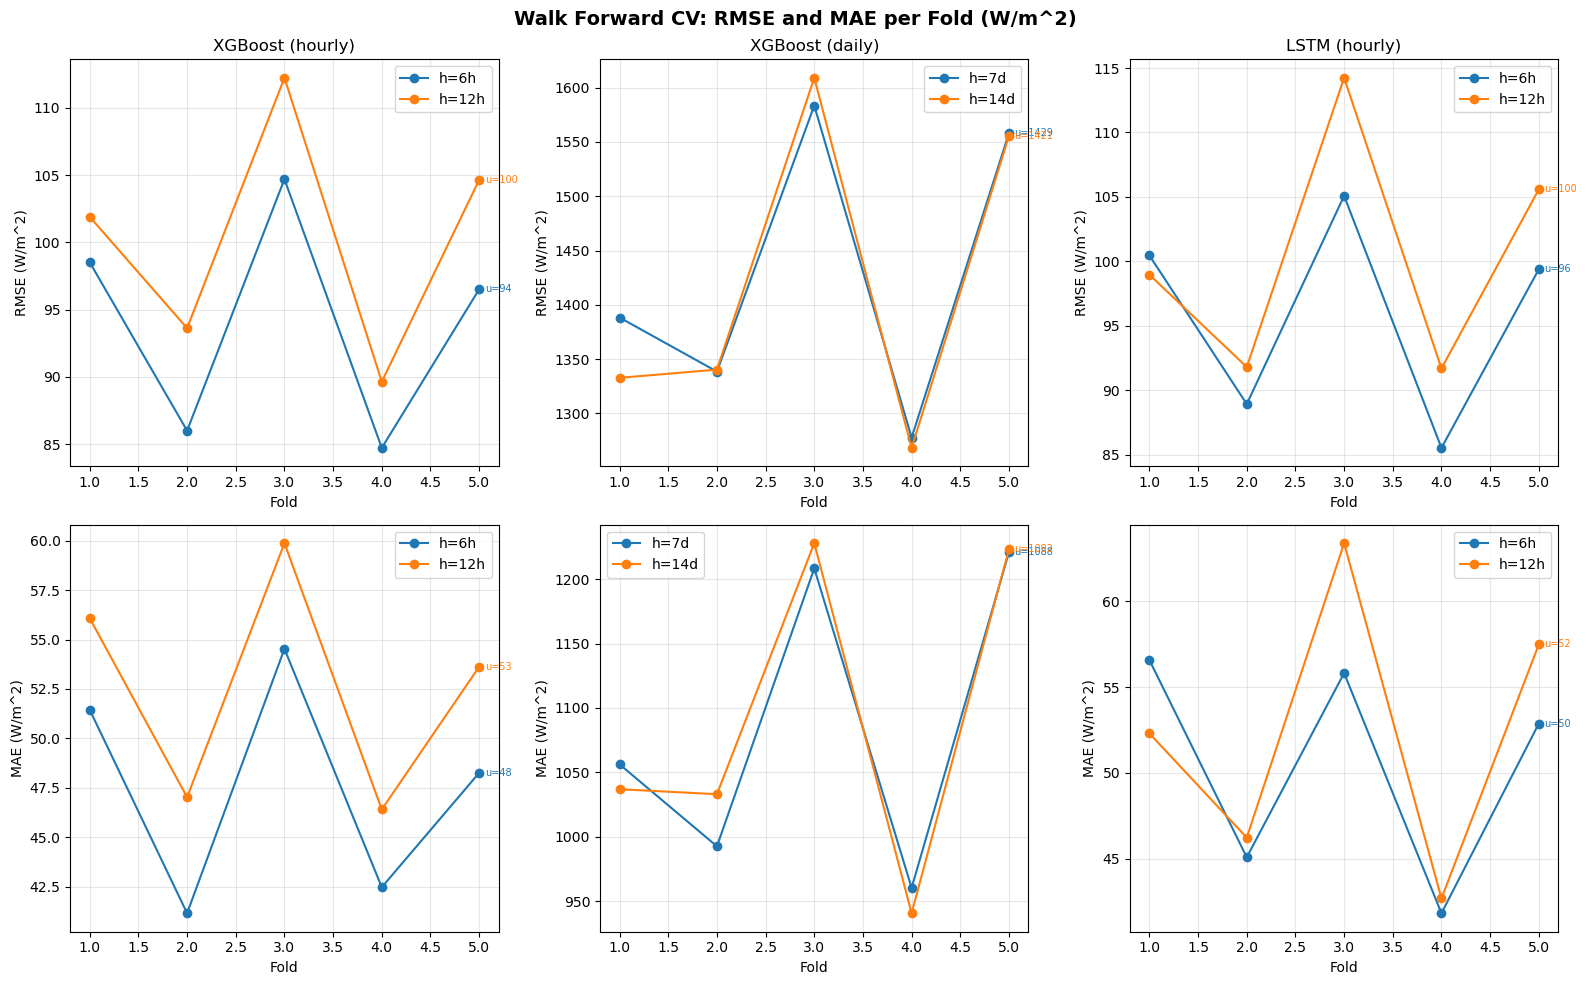

Plot saved to outputs/cv_rmse_per_fold.png


In [11]:
# PLOT: RMSE AND MAE PER FOLD
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Walk Forward CV: RMSE and MAE per Fold (W/m^2)", fontsize=14, fontweight="bold")

subplot_cfg = [
    ("XGBoost", "XGBoost (hourly)", SHORT_HORIZONS, "h"), ("XGBoost_daily", "XGBoost (daily)", MEDIUM_HORIZONS, "d"), ("LSTM", "LSTM (hourly)", SHORT_HORIZONS, "h"),
]

for col, (model, title, horizons, suffix) in enumerate(subplot_cfg):
    for row, (metric, ylabel) in enumerate([("rmse", "RMSE (W/m^2)"), ("mae", "MAE (W/m^2)")]):
        ax = axes[row][col]
        for h in horizons:
            rows = [r for r in all_results if r["model"] == model and r["horizon"] == f"{h}{suffix}" and r["fold"] != "aggregate"]
            folds = [r["fold"] for r in rows]
            vals = [r[metric] for r in rows]
            line, = ax.plot(folds, vals, marker="o", label=f"h={h}{suffix}")
            if vals:
                ax.annotate(f"u={np.mean(vals):.0f}", xy=(folds[-1], vals[-1]), xytext=(4, 0), textcoords="offset points", fontsize=7, color=line.get_color(), va="center")
        if row == 0:
            ax.set_title(title)
        ax.set_xlabel("Fold")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/cv_rmse_per_fold.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to outputs/cv_rmse_per_fold.png")

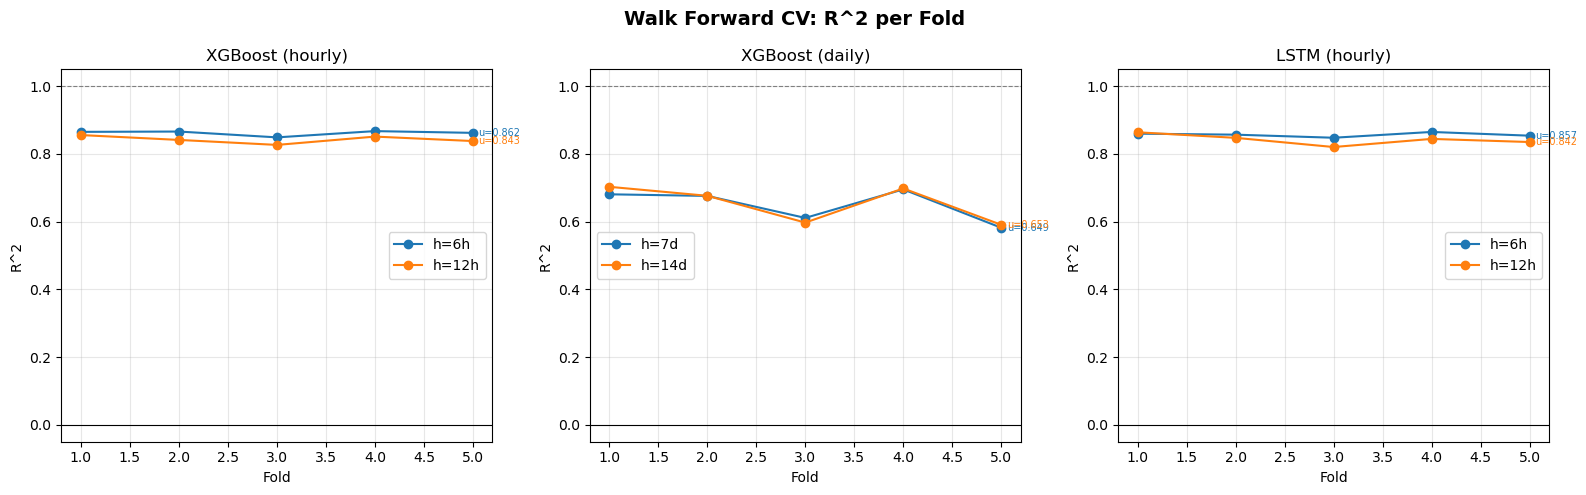

Plot saved to outputs/cv_r2_per_fold.png


In [12]:
# PLOT: R^2 PER FOLD
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Walk Forward CV: R^2 per Fold", fontsize=14, fontweight="bold")

subplot_cfg = [
    ("XGBoost", "XGBoost (hourly)", SHORT_HORIZONS, "h"), ("XGBoost_daily", "XGBoost (daily)", MEDIUM_HORIZONS, "d"), ("LSTM", "LSTM (hourly)", SHORT_HORIZONS, "h"),
]

for col, (model, title, horizons, suffix) in enumerate(subplot_cfg):
    ax = axes[col]
    for h in horizons:
        rows = [r for r in all_results if r["model"] == model and r["horizon"] == f"{h}{suffix}" and r["fold"] != "aggregate"]
        folds = [r["fold"] for r in rows]
        r2s = [r["r2"] for r in rows]
        line, = ax.plot(folds, r2s, marker="o", label=f"h={h}{suffix}")
        if r2s:
            ax.annotate(f"u={np.mean(r2s):.3f}", xy=(folds[-1], r2s[-1]), xytext=(4, 0), textcoords="offset points", fontsize=7, color=line.get_color(), va="center")
    ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("Fold")
    ax.set_ylabel("R^2")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/cv_r2_per_fold.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to outputs/cv_r2_per_fold.png")

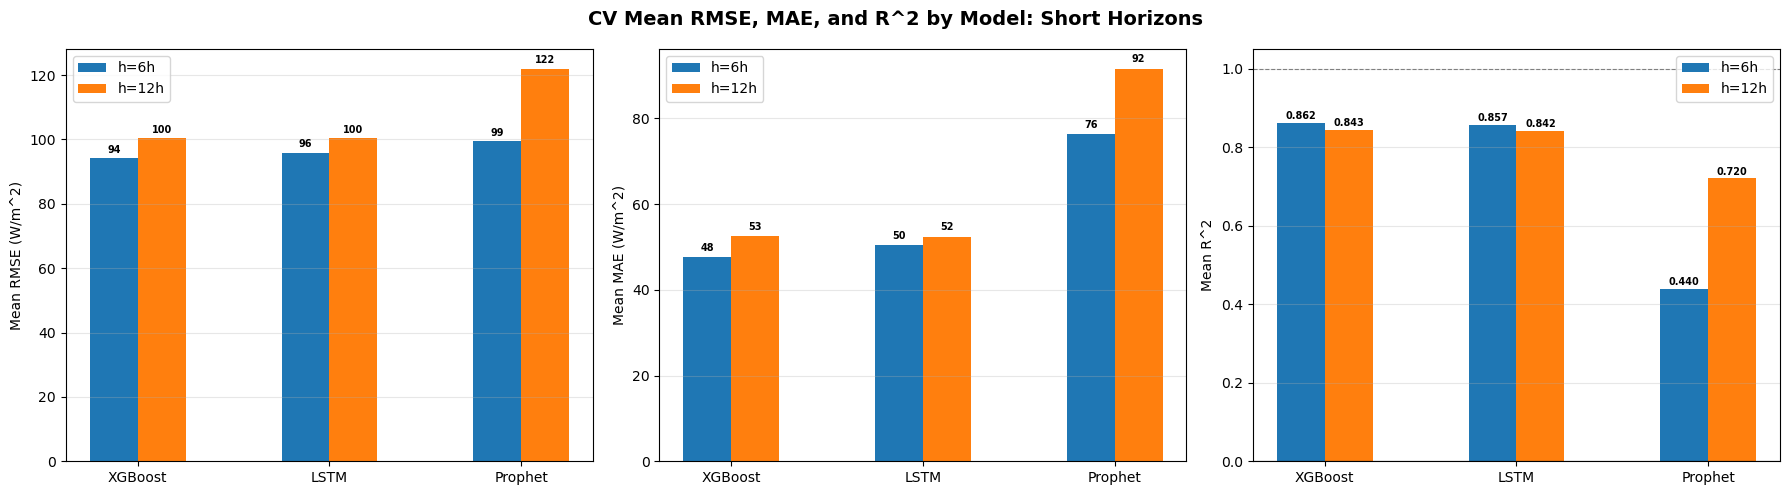

Plot saved to outputs/cv_model_comparison_short.png


In [13]:
# PLOT: Model comparison - mean RMSE, MAE, and R^2 at short horizons (XGBoost vs LSTM vs Prophet)
models = ["XGBoost", "LSTM", "Prophet"]
n_horizons = len(SHORT_HORIZONS)
bar_width = 0.25
x = np.arange(len(models))

# Warn upfront if Prophet results are missing entirely
prophet_check = [r for r in all_results if r["model"] == "Prophet"]
if not prophet_check:
    print("WARNING: No Prophet results found in all_results. Prophet CV cells may not have completed. Prophet bars will be omitted from the chart.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CV Mean RMSE, MAE, and R^2 by Model: Short Horizons", fontsize=14, fontweight="bold")

for metric, ax, ylabel in [("rmse", axes[0], "Mean RMSE (W/m^2)"), ("mae", axes[1], "Mean MAE (W/m^2)"), ("r2", axes[2], "Mean R^2")]:
    for i, h in enumerate(SHORT_HORIZONS):
        vals = []
        missing_models = []
        for model in models:
            rows = [r for r in all_results if r["model"] == model and r["horizon"] == f"{h}h"]
            if rows:
                vals.append(np.mean([r[metric] for r in rows]))
            else:
                vals.append(np.nan)
                missing_models.append(model)

        if missing_models:
            print(f"h={h}h - no results for: {missing_models}. Bars will be skipped.")

        valid_x = [x[j] + i * bar_width for j, v in enumerate(vals) if not np.isnan(v)]
        valid_vals = [v for v in vals if not np.isnan(v)]

        bars = ax.bar(valid_x, valid_vals, width=bar_width, label=f"h={h}h")
        for bar, val in zip(bars, valid_vals):
            fmt = f"{val:.3f}" if metric == "r2" else f"{val:.0f}"
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (0.005 if metric == "r2" else 1), fmt, ha="center", va="bottom", fontsize=7, fontweight="bold")

        for j, v in enumerate(vals):
            if np.isnan(v):
                ax.annotate("no data", xy=(x[j] + i * bar_width, 0), ha="center", va="bottom", fontsize=7, color="red", rotation=90)

    ax.set_xticks(x + bar_width * (n_horizons - 1) / 2)
    ax.set_xticklabels(models)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    if metric == "r2":
        ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")
        ax.axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("outputs/cv_model_comparison_short.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to outputs/cv_model_comparison_short.png")

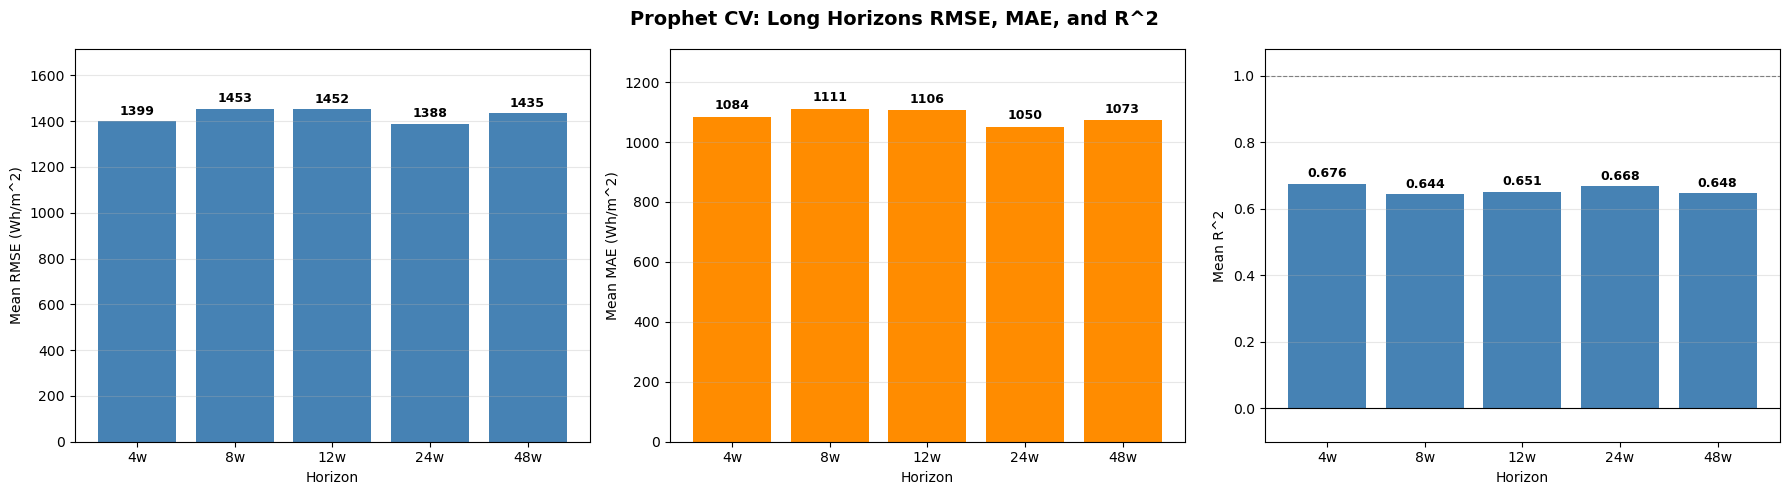

Plot saved to outputs/cv_prophet_long_horizon.png


In [14]:
# PLOT: Prophet long horizon RMSE, MAE, and R^2
prophet_long = [r for r in all_results if r["model"] == "Prophet_long" and r["horizon"].endswith("d")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Prophet CV: Long Horizons RMSE, MAE, and R^2", fontsize=14, fontweight="bold")

if prophet_long:
    horizons_long = [r["horizon"] for r in prophet_long]
    week_labels = [f"{int(h[:-1]) // 7}w" for h in horizons_long]
    rmses_long = [r["rmse"] for r in prophet_long]
    maes_long = [r["mae"]  for r in prophet_long]
    r2s_long = [float(r["r2"]) for r in prophet_long]

    # RMSE
    ax = axes[0]
    bars = ax.bar(week_labels, rmses_long, color="steelblue")
    for bar, val in zip(bars, rmses_long):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15, f"{val:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_xlabel("Horizon")
    ax.set_ylabel("Mean RMSE (Wh/m^2)")
    ax.set_ylim(0, max(rmses_long) * 1.18)
    ax.grid(alpha=0.3, axis="y")

    # MAE
    ax = axes[1]
    bars = ax.bar(week_labels, maes_long, color="darkorange")
    for bar, val in zip(bars, maes_long):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15, f"{val:.0f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_xlabel("Horizon")
    ax.set_ylabel("Mean MAE (Wh/m^2)")
    ax.set_ylim(0, max(maes_long) * 1.18)
    ax.grid(alpha=0.3, axis="y")

    # R^2 - now always a real value computed from df_cv_long y vs yhat
    ax = axes[2]
    bars = ax.bar(week_labels, r2s_long, color="steelblue")
    for bar, val in zip(bars, r2s_long):
        label_y = bar.get_height() + 0.01 if val >= 0 else bar.get_height() - 0.05
        ax.text(bar.get_x() + bar.get_width() / 2, label_y, f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(min(-0.1, min(r2s_long) - 0.05), 1.08)
    ax.set_xlabel("Horizon")
    ax.set_ylabel("Mean R^2")
    ax.grid(alpha=0.3, axis="y")

else:
    for ax in axes:
        ax.text(0.5, 0.5, "No Prophet long horizon results found.\nRe-run Prophet CV cells first.", ha="center", va="center", transform=ax.transAxes, color="red", fontsize=12)
    print("WARNING: No Prophet_long results found. Prophet long horizon CV may not have completed.")

plt.tight_layout()
plt.savefig("outputs/cv_prophet_long_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to outputs/cv_prophet_long_horizon.png")